In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

df = pd.read_hdf("../reports/test_scored.h5", "df")
print(f"Shape: {df.shape}")

Shape: (17578, 107)


In [3]:
TARGET = "installed_decision"

# ── LEAK-FREE FEATURES ONLY ──
#
# EXCLUDED (LEAKY) — built from TEST window via build_partner_ops_vector():
#   se_30d, decline_rate_30d, installs_30d, declines_30d, total_decisions,
#   median_response_min, mean_response_min, expected_daily_slots, active_days,
#   nmbr_active_leads, long_held_leads_24h, queue_velocity,
#   active_tickets, median_tat_min, max_tat_min, ticket_resolution_rate,
#   late_arrive_median, late_arrive_max, late_severity_max, late_close_penalty,
#   plan_created_rate, planning_strength,
#   operational_score, capacity_score, reliability_score, infrastructure_score,
#   composite_score, spatial_shrunk (contains ops), confidence_tier, r_serviceable
#
# SAFE — all derived from TRAINING data or infrastructure:

FEATURES = [
    # SPATIAL — Gaussian KDE from training sources
    "predicted_field_hex",
    "contested_field",
    # HEX — training install/decline counts, shrunk
    "parent_se",
    "parent_total",
    "parent_color_numeric",
    "n_covering_partners",
    # HOP — training hex neighbor SE aggregates
    "hop1_se_wmean", "hop2_se_wmean", "hop3_se_wmean",
    "se_gradient_1to3", "se_confirmed", "isolation_ratio",
    # BOUNDARY — training cluster geometry
    "dist_to_boundary_edge_point_hex",
    "dist_to_cluster_center_point_hex",
    "depth_score_point_hex",
    "mean_dist_to_edge_m", "mean_dist_to_center_m",
    "total_area_boundaries", "nmbr_overlap_clusters",
    "nearest_boundary_dist_m", "nmbr_boundaries_within_100m",
    # GEOMETRIC PATTERN — from training install points around lead
    "local_anisotropy", "local_density", "hull_area",
    "linearity_score", "spread_m",
    "dense_score", "gully_score", "sparse_score",
    # LEAD-LEVEL
    "hard_density",  # BallTree count from training settled decisions
    "min_dist",      # G1 distance to nearest router (infrastructure)
]

available = [f for f in FEATURES if f in df.columns]
missing = [f for f in FEATURES if f not in df.columns]
print(f"Using {len(available)} features, missing {len(missing)}: {missing}")

Using 31 features, missing 0: []


In [4]:
# ── PREP ──
X = df[available].copy()
y = df[TARGET].copy()

mask = y.notna()
X, y = X[mask], y[mask]
X = X.fillna(-999)

print(f"Samples: {len(X)}, Features: {X.shape[1]}, Install rate: {y.mean():.4f}")

Samples: 17578, Features: 31, Install rate: 0.5960


In [5]:
# ── TRAIN / TEST SPLIT ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y.astype(int)
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")
print(f"Train SE: {y_train.mean():.4f}  Test SE: {y_test.mean():.4f}")

Train: 12304  Test: 5274
Train SE: 0.5961  Test SE: 0.5959


In [6]:
# ── FIT ──
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=50,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
print(f"Train R²: {rf.score(X_train, y_train):.4f}")
print(f"Test  R²: {rf.score(X_test, y_test):.4f}")

Train R²: 0.1247
Test  R²: 0.0610


In [7]:
# ── FEATURE IMPORTANCE ──
imp = pd.Series(rf.feature_importances_, index=available).sort_values(ascending=False)
print(imp.round(4).to_string())
print(f"\nTop 10:")
for feat, val in imp.head(10).items():
    bar = "█" * int(val * 200)
    print(f"  {feat:40s} {val:.4f} {bar}")

contested_field                     0.0881
predicted_field_hex                 0.0720
parent_se                           0.0700
parent_color_numeric                0.0432
parent_total                        0.0429
hull_area                           0.0426
min_dist                            0.0382
hard_density                        0.0355
hop2_se_wmean                       0.0342
hop1_se_wmean                       0.0313
dist_to_cluster_center_point_hex    0.0313
total_area_boundaries               0.0313
mean_dist_to_center_m               0.0310
mean_dist_to_edge_m                 0.0303
local_density                       0.0295
n_covering_partners                 0.0292
depth_score_point_hex               0.0274
se_confirmed                        0.0272
hop3_se_wmean                       0.0265
dense_score                         0.0256
se_gradient_1to3                    0.0252
spread_m                            0.0249
local_anisotropy                    0.0249
dist_to_bou

In [8]:
# ── DECILE PERFORMANCE (TEST SET ONLY — honest eval) ──
preds = rf.predict(X_test)
eval_df = pd.DataFrame({"y": y_test.values, "pred": preds})
eval_df["decile"] = pd.qcut(eval_df["pred"], q=10, labels=False, duplicates="drop") + 1

decile_tbl = eval_df.groupby("decile").agg(
    n=("y", "count"),
    installs=("y", "sum"),
    pred_mean=("pred", "mean"),
).assign(se=lambda x: x.installs / x.n)

gap = decile_tbl["se"].iloc[-1] - decile_tbl["se"].iloc[0]
monotonic = all(decile_tbl["se"].diff().dropna() >= 0)

print(f"TEST SET decile gap: {gap:.4f}  Monotonic: {monotonic}")
print(decile_tbl.round(4))

TEST SET decile gap: 0.4242  Monotonic: False
          n  installs  pred_mean      se
decile                                  
1       528       188     0.4210  0.3561
2       527       224     0.5024  0.4250
3       527       278     0.5399  0.5275
4       528       312     0.5667  0.5909
5       527       311     0.5900  0.5901
6       527       323     0.6117  0.6129
7       528       348     0.6358  0.6591
8       527       356     0.6598  0.6755
9       527       391     0.6877  0.7419
10      528       412     0.7523  0.7803


In [9]:
# ── FULL-DATA PREDICTION + COMPARISON ──
df["rf_score"] = rf.predict(df[available].fillna(-999))
df["rf_decile"] = pd.qcut(df["rf_score"], q=10, labels=False, duplicates="drop") + 1

full_tbl = df.groupby("rf_decile").agg(
    n=("mobile", "count"),
    installs=(TARGET, "sum"),
).assign(se=lambda x: x.installs / x.n)

full_gap = full_tbl["se"].iloc[-1] - full_tbl["se"].iloc[0]
full_mono = all(full_tbl["se"].diff().dropna() >= 0)
print(f"Full data — gap: {full_gap:.4f}  monotonic: {full_mono}")
print(full_tbl.round(4))

# Compare
def decile_gap(score_col):
    d = pd.qcut(df[score_col], q=10, labels=False, duplicates="drop") + 1
    tbl = df.groupby(d).agg(n=(TARGET, "count"), inst=(TARGET, "sum"))
    tbl["se"] = tbl["inst"] / tbl["n"]
    return tbl["se"].iloc[-1] - tbl["se"].iloc[0], all(tbl["se"].diff().dropna() >= 0)

print(f"\n{'Score':25s}  {'Gap':>8s}  {'Mono':>5s}")
print("-" * 42)
for col in ["rf_score", "composite_score", "spatial_shrunk"]:
    if col in df.columns:
        g, m = decile_gap(col)
        print(f"{col:25s}  {g:8.4f}  {str(m):>5s}")

Full data — gap: 0.6024  monotonic: True
              n  installs      se
rf_decile                        
1          1758       483  0.2747
2          1758       638  0.3629
3          1758       814  0.4630
4          1757       974  0.5544
5          1758       999  0.5683
6          1758      1106  0.6291
7          1757      1207  0.6870
8          1758      1289  0.7332
9          1758      1425  0.8106
10         1758      1542  0.8771

Score                           Gap   Mono
------------------------------------------
rf_score                     0.6024   True
composite_score              0.1126  False
spatial_shrunk               0.2053   True


In [10]:
# ══════════════════════════════════════════════
# CORRELATION ANALYSIS
# ══════════════════════════════════════════════

# 1. Each feature's correlation with target
feat_df = df[available + [TARGET]].copy()
corr_target = feat_df.corr()[TARGET].drop(TARGET).sort_values(ascending=False)

print("Correlation with installed_decision:\n")
for feat, val in corr_target.items():
    bar = "█" * int(abs(val) * 200)
    sign = "+" if val >= 0 else "-"
    print(f"  {sign}{abs(val):.4f}  {feat:40s}  {bar}")

Correlation with installed_decision:

  +0.1389  parent_se                                 ███████████████████████████
  +0.1096  parent_color_numeric                      █████████████████████
  +0.1044  predicted_field_hex                       ████████████████████
  +0.1027  contested_field                           ████████████████████
  +0.0983  hull_area                                 ███████████████████
  +0.0919  nmbr_overlap_clusters                     ██████████████████
  +0.0859  hop1_se_wmean                             █████████████████
  +0.0776  total_area_boundaries                     ███████████████
  +0.0690  se_gradient_1to3                          █████████████
  +0.0658  spread_m                                  █████████████
  +0.0583  hop2_se_wmean                             ███████████
  +0.0437  se_confirmed                              ████████
  +0.0369  dense_score                               ███████
  +0.0292  hop3_se_wmean                           

In [11]:
# 2. Feature-to-feature: flag high collinearity (|r| > 0.7)
corr_matrix = df[available].corr()

high_corr = []
for i in range(len(available)):
    for j in range(i + 1, len(available)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append((available[i], available[j], round(r, 3)))

high_corr.sort(key=lambda x: -abs(x[2]))

print(f"Highly correlated pairs (|r| > 0.7): {len(high_corr)}\n")
for a, b, r in high_corr:
    print(f"  {r:+.3f}  {a}  <->  {b}")

Highly correlated pairs (|r| > 0.7): 15

  -0.963  dense_score  <->  sparse_score
  +0.886  dist_to_cluster_center_point_hex  <->  depth_score_point_hex
  +0.882  parent_total  <->  hard_density
  +0.878  hop3_se_wmean  <->  se_confirmed
  -0.808  dist_to_boundary_edge_point_hex  <->  depth_score_point_hex
  +0.803  local_anisotropy  <->  gully_score
  +0.798  hop2_se_wmean  <->  se_confirmed
  +0.774  parent_se  <->  nmbr_overlap_clusters
  +0.755  hull_area  <->  spread_m
  +0.736  hop1_se_wmean  <->  hop2_se_wmean
  +0.736  hop2_se_wmean  <->  hop3_se_wmean
  +0.735  hop1_se_wmean  <->  se_confirmed
  +0.722  total_area_boundaries  <->  nmbr_overlap_clusters
  +0.711  parent_total  <->  n_covering_partners
  +0.706  n_covering_partners  <->  hard_density


In [12]:
# 3. Importance vs correlation comparison
comparison = pd.DataFrame({
    "importance": imp,
    "corr_target": corr_target,
}).dropna().sort_values("importance", ascending=False)

print(f"{'Feature':40s}  {'Imp':>6s}  {'Corr':>6s}")
print("-" * 56)
for feat, row in comparison.iterrows():
    print(f"{feat:40s}  {row['importance']:6.4f}  {row['corr_target']:+6.4f}")

Feature                                      Imp    Corr
--------------------------------------------------------
contested_field                           0.0881  +0.1027
predicted_field_hex                       0.0720  +0.1044
parent_se                                 0.0700  +0.1389
parent_color_numeric                      0.0432  +0.1096
parent_total                              0.0429  -0.0216
hull_area                                 0.0426  +0.0983
min_dist                                  0.0382  -0.0102
hard_density                              0.0355  -0.0099
hop2_se_wmean                             0.0342  +0.0583
hop1_se_wmean                             0.0313  +0.0859
dist_to_cluster_center_point_hex          0.0313  -0.0313
total_area_boundaries                     0.0313  +0.0776
mean_dist_to_center_m                     0.0310  +0.0087
mean_dist_to_edge_m                       0.0303  +0.0251
local_density                             0.0295  +0.0098
n_covering_partn

In [13]:
# ── 1. SINGLE TREE VISUALIZATION (text) ──
from sklearn.tree import export_text

# Pick one shallow tree from the forest
single_tree = rf.estimators_[0]
tree_text = export_text(single_tree, feature_names=available, max_depth=4)
print(tree_text)

|--- mean_dist_to_edge_m <= 15.67
|   |--- parent_total <= 7.50
|   |   |--- spread_m <= 12.65
|   |   |   |--- dist_to_boundary_edge_point_hex <= 63.64
|   |   |   |   |--- n_covering_partners <= 1.50
|   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |--- n_covering_partners >  1.50
|   |   |   |   |   |--- value: [0.39]
|   |   |   |--- dist_to_boundary_edge_point_hex >  63.64
|   |   |   |   |--- value: [0.66]
|   |   |--- spread_m >  12.65
|   |   |   |--- hull_area <= 4210.75
|   |   |   |   |--- parent_se <= 0.45
|   |   |   |   |   |--- value: [0.60]
|   |   |   |   |--- parent_se >  0.45
|   |   |   |   |   |--- value: [0.81]
|   |   |   |--- hull_area >  4210.75
|   |   |   |   |--- value: [0.60]
|   |--- parent_total >  7.50
|   |   |--- contested_field <= -0.46
|   |   |   |--- isolation_ratio <= 1.42
|   |   |   |   |--- dist_to_boundary_edge_point_hex <= 13.76
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- dist_to_boundary_edge

In [14]:
# ── RF INTERPRETABILITY VISUALS ──
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.inspection import partial_dependence

plt.rcParams.update({
    "figure.facecolor": "#0a0e17",
    "axes.facecolor": "#111827",
    "axes.edgecolor": "#1e293b",
    "axes.labelcolor": "#9ca3af",
    "xtick.color": "#6b7280",
    "ytick.color": "#6b7280",
    "text.color": "#e2e8f0",
    "grid.color": "#1e293b",
    "font.family": "monospace",
    "font.size": 10,
})
AMBER = "#f0b429"
BLUE = "#60a5fa"
GREEN = "#10b981"
RED = "#ef4444"
PURPLE = "#a78bfa"
CYAN = "#22d3ee"
GRAY = "#4a5568"

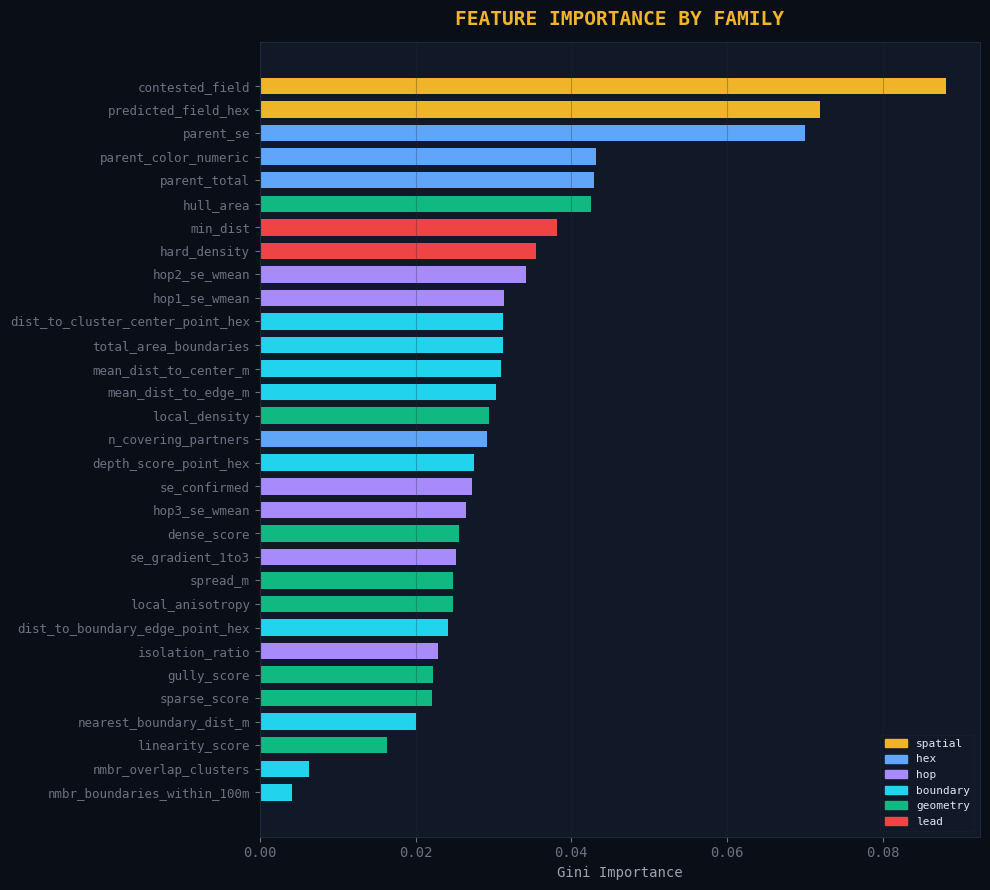

In [15]:
# ── 1. FEATURE IMPORTANCE — horizontal bar, colored by family ──
family_map = {
    "contested_field": "spatial", "predicted_field_hex": "spatial",
    "parent_se": "hex", "parent_color_numeric": "hex", "parent_total": "hex", "n_covering_partners": "hex",
    "hop1_se_wmean": "hop", "hop2_se_wmean": "hop", "hop3_se_wmean": "hop",
    "se_gradient_1to3": "hop", "se_confirmed": "hop", "isolation_ratio": "hop",
    "dist_to_boundary_edge_point_hex": "boundary", "dist_to_cluster_center_point_hex": "boundary",
    "depth_score_point_hex": "boundary", "mean_dist_to_edge_m": "boundary",
    "mean_dist_to_center_m": "boundary", "total_area_boundaries": "boundary",
    "nmbr_overlap_clusters": "boundary", "nearest_boundary_dist_m": "boundary",
    "nmbr_boundaries_within_100m": "boundary",
    "local_anisotropy": "geometry", "local_density": "geometry", "hull_area": "geometry",
    "linearity_score": "geometry", "spread_m": "geometry",
    "dense_score": "geometry", "gully_score": "geometry", "sparse_score": "geometry",
    "hard_density": "lead", "min_dist": "lead",
}
fam_colors = {"spatial": AMBER, "hex": BLUE, "hop": PURPLE, "boundary": CYAN, "geometry": GREEN, "lead": RED}

imp_sorted = imp.sort_values(ascending=True)
colors = [fam_colors.get(family_map.get(f, ""), GRAY) for f in imp_sorted.index]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(range(len(imp_sorted)), imp_sorted.values, color=colors, height=0.7, edgecolor="none")
ax.set_yticks(range(len(imp_sorted)))
ax.set_yticklabels(imp_sorted.index, fontsize=9)
ax.set_xlabel("Gini Importance")
ax.set_title("FEATURE IMPORTANCE BY FAMILY", fontsize=14, fontweight="bold", color=AMBER, pad=12)
ax.grid(axis="x", alpha=0.3)

patches = [mpatches.Patch(color=c, label=k) for k, c in fam_colors.items()]
ax.legend(handles=patches, loc="lower right", fontsize=8, framealpha=0.3, edgecolor="#1e293b")
plt.tight_layout()
plt.show()

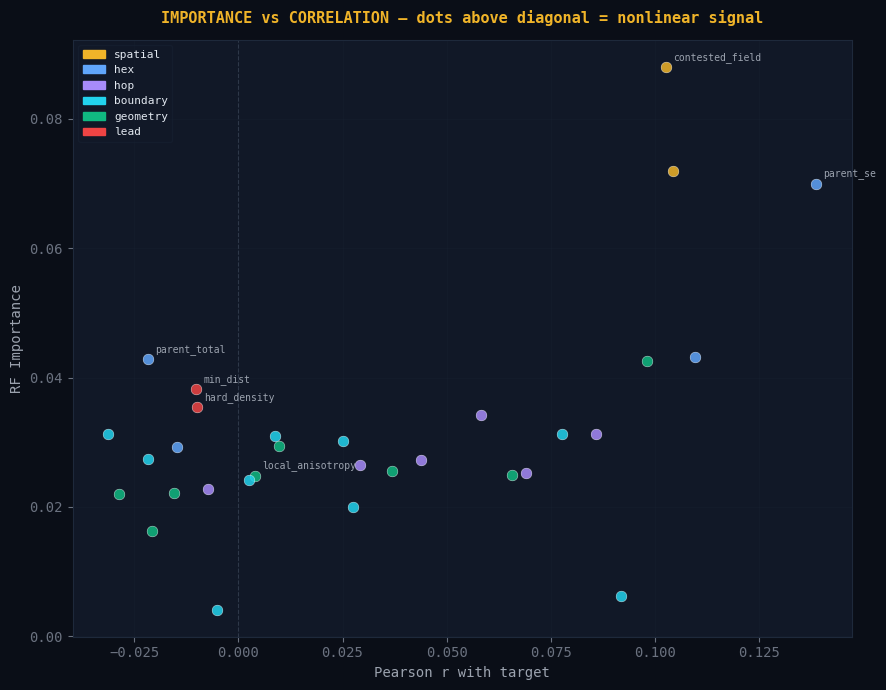

In [16]:
# ── 2. IMPORTANCE vs CORRELATION scatter ──
fig, ax = plt.subplots(figsize=(9, 7))

for feat in imp.index:
    c = fam_colors.get(family_map.get(feat, ""), GRAY)
    corr_val = corr_target.get(feat, 0)
    imp_val = imp[feat]
    ax.scatter(corr_val, imp_val, c=c, s=60, alpha=0.85, edgecolor="white", linewidth=0.3, zorder=3)

# Label top divergent features (high imp, low/negative corr)
for feat in ["parent_total", "min_dist", "hard_density", "local_anisotropy", "contested_field", "parent_se"]:
    if feat in imp.index:
        ax.annotate(feat, (corr_target[feat], imp[feat]),
                    fontsize=7, color="#9ca3af", ha="left",
                    xytext=(5, 5), textcoords="offset points")

ax.axvline(0, color=GRAY, linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Pearson r with target")
ax.set_ylabel("RF Importance")
ax.set_title("IMPORTANCE vs CORRELATION — dots above diagonal = nonlinear signal",
             fontsize=11, fontweight="bold", color=AMBER, pad=12)
ax.grid(alpha=0.2)

patches = [mpatches.Patch(color=c, label=k) for k, c in fam_colors.items()]
ax.legend(handles=patches, loc="upper left", fontsize=8, framealpha=0.3, edgecolor="#1e293b")
plt.tight_layout()
plt.show()

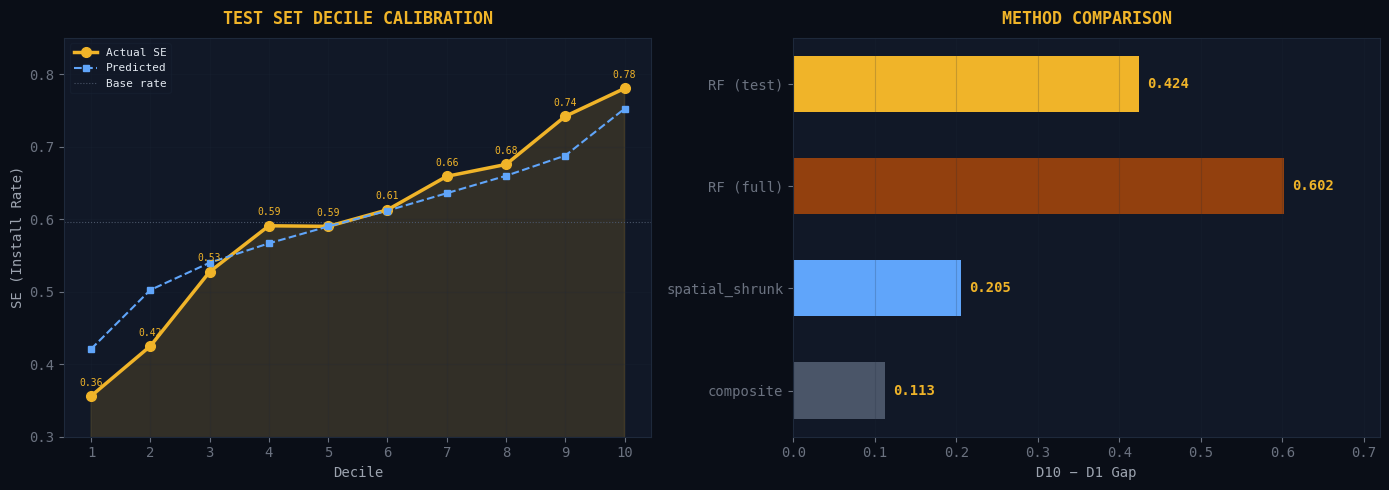

In [17]:
# ── 3. DECILE CALIBRATION — actual vs predicted ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Test set decile
deciles = list(range(1, 11))
actual_se = [0.3561, 0.4250, 0.5275, 0.5909, 0.5901, 0.6129, 0.6591, 0.6755, 0.7419, 0.7803]
pred_se =   [0.4210, 0.5024, 0.5399, 0.5667, 0.5900, 0.6117, 0.6358, 0.6598, 0.6877, 0.7523]

ax1.fill_between(deciles, actual_se, alpha=0.15, color=AMBER)
ax1.plot(deciles, actual_se, "o-", color=AMBER, linewidth=2.5, markersize=7, label="Actual SE", zorder=3)
ax1.plot(deciles, pred_se, "s--", color=BLUE, linewidth=1.5, markersize=5, label="Predicted", zorder=3)
ax1.axhline(0.596, color=GRAY, linestyle=":", linewidth=0.8, label="Base rate")

for i, (d, se) in enumerate(zip(deciles, actual_se)):
    ax1.annotate(f"{se:.2f}", (d, se), fontsize=7, ha="center", va="bottom",
                 xytext=(0, 6), textcoords="offset points", color=AMBER)

ax1.set_xlabel("Decile")
ax1.set_ylabel("SE (Install Rate)")
ax1.set_title("TEST SET DECILE CALIBRATION", fontsize=12, fontweight="bold", color=AMBER, pad=10)
ax1.set_xticks(deciles)
ax1.legend(fontsize=8, framealpha=0.3, edgecolor="#1e293b")
ax1.grid(alpha=0.2)
ax1.set_ylim(0.3, 0.85)

# Method comparison
methods = ["RF (test)", "RF (full)", "spatial_shrunk", "composite"]
gaps = [0.4242, 0.6024, 0.2053, 0.1126]
bar_colors = [AMBER, "#92400e", BLUE, GRAY]

bars = ax2.barh(methods, gaps, color=bar_colors, height=0.55, edgecolor="none")
for bar, gap in zip(bars, gaps):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f"{gap:.3f}", va="center", fontsize=10, fontweight="bold", color=AMBER)

ax2.set_xlabel("D10 − D1 Gap")
ax2.set_title("METHOD COMPARISON", fontsize=12, fontweight="bold", color=AMBER, pad=10)
ax2.set_xlim(0, 0.72)
ax2.grid(axis="x", alpha=0.2)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()